**Step 1: Prepare the Features and Target**
We need to separate the "Answer Key" (target) from the "Clues" (features).

In [111]:
import pandas as pd
import numpy as np

In [112]:
# read the data from raw
df_master= pd.read_csv('../data/raw/master.csv')
df_master.shape

(300000, 26)

In [113]:
model_features = ['asset_type', 'odometer', 'utilization_7day_avg', 'days_since_service', 'historical_failure_count',
 'vibration_index', 'vibration_7day_std', 'temp_delta', 'oil_press_std_7d', 'load_7day_std', 'stress_7day_avg']

In [ ]:
# import the model_features 
import pickle

with open("../models/pickle/model_features.pkl", 'rb') as f:
    loaded_list = pickle.load(f)

In [114]:
print(df_master[model_features].shape)
df_master[model_features].head()


(300000, 11)


,asset_type,odometer,utilization_7day_avg,days_since_service,historical_failure_count,vibration_index,vibration_7day_std,temp_delta,oil_press_std_7d,load_7day_std,stress_7day_avg
0,Light Duty,26083,NaN,24,0,12.141658,NaN,195.071966,NaN,NaN,NaN
1,Light Duty,26313,NaN,25,0,10.542560,NaN,190.759172,NaN,NaN,NaN
2,Light Duty,26648,NaN,26,0,9.572207,NaN,198.361329,NaN,NaN,NaN
3,Light Duty,26802,NaN,27,0,10.355551,NaN,219.127713,NaN,NaN,NaN
4,Light Duty,26990,NaN,28,0,9.708306,NaN,198.382446,NaN,NaN,NaN


## 5. Temporal Split

There are two primary ways to split time-series data, and they serve different "Data Science" purposes.

Given our project objective—building a robust classification pipeline—we need to choose the one that proves our model works in a real-world fleet environment.

1. Temporal Split

This is best for answering: "If I train on last year's data, can I predict next month's failures?"

Pros: It perfectly mimics real-time deployment. It handles "Seasonality" or "Global Trends" (like the simulation getting more "shaky" after Day 200).

Cons: If the data have the same Asset_001 in both the "Past" and the "Future," the model might just learn that Asset_001 is a "bad truck" rather than learning the symptoms of a bad truck.

2. Asset-Based Split 

This is best for answering: "If I buy a new truck tomorrow, can my model predict its failures?"

Pros: It proves the model is learning mechanical physics (heat/vibration) rather than just memorizing specific vehicle IDs.

The "Gold Standard" Solution: The Combined Split

In professional BI and Data Science, the most robust way is to combine both. We use the Temporal Split (Days 0–240) but we also ensure we handle the Categorical Encoding and Scaling within that timeframe.

We are going evaluate threee models, which are Random Forest, XGBoost, LightGBM. These are tree-based models, and tree models do NOT require scaling.

Trees split by thresholds(vibration_std > 1.8). Scaling doesn't change the split logic.

In [115]:
# 1. Define the cutoff for a 80/20 time split
cutoff_day = 240 # Train model on this time line data
end_day = 270 # Test model on (240 -270) time line data

# 2. Filter the Data
train_df = df_master[df_master['date'] < cutoff_day].copy()
test_df = df_master[(df_master['date'] >= cutoff_day) & (df_master['date'] <= end_day)].copy()

# 3. Encode & Scale (Crucial Step)
# We must apply encoding/scaling AFTER the split to prevent "Look-ahead" bias
X_train = pd.get_dummies(train_df[model_features], columns=['asset_type'], drop_first=True)
X_test = pd.get_dummies(test_df[model_features], columns=['asset_type'], drop_first=True)

# 4. Handle NaNs and Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# List of numeric columns from model_features
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols].fillna(X_train[numeric_cols].median()))
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols].fillna(X_train[numeric_cols].median()))

# When using pd.get_dummies, train and test may get different columns if a category appears only in one.
#train: Light Duty, Medium Duty , test: Heavy Duty, Medium Duty
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# our target is already in 0 and 1 format, there is no need of any numeric conversiton
y_train = train_df['target']
y_test = test_df['target']

print(f"Training on Past (Days 0-239): {X_train.shape}")
print(f"Testing on Future (Days 240-270): {X_test.shape}")

Training on Past (Days 0-239): (240000, 12)
Testing on Future (Days 240-270): (31000, 12)


Buffer Logic: correctly identified the "Censored Data" problem. By dropping the last 30 days, it is ensure that every "0" in test set is a true zero, not just a vehicle that was about to fail on day 305.

Data Integrity: By using the median of the training set to fill NaNs in the test set, it's ensure that model doesn't "peek" into the future statistics of the fleet.

**Handle imbalance using SMOTE**

SMOTE creates synthetic minority samples so the model learns the failure patterns better.

Does balanced data give "correct" results? 
The "Correct" is tricky.
The Benefit: It forces the model to find a decision boundary that actually respects the features of the "1" group.

The Risk: It can make the model "over-optimistic," leading to more False Positives (predicting "1" for someone who is actually a "0").

The Verdict: We train on balanced data (SMOTE) so the model learns the patterns, but we always validate on the original, imbalanced test data. That is the only way to get a "correct" real-world performance metric.

This works, but SMOTE is applied before cross-validation, which can leak information between folds.

for our data, better approach is to embed SMOTE inside the each model pipeline, so it runs inside each CV fold separately.

This is the correct production workflow used with scikit-learn and imbalanced-learn.

In [ ]:
# from imblearn.over_sampling import SMOTE

# sm = SMOTE(random_state=42)

# X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Original class distribution:")
# print(y_train.value_counts())

# print("After SMOTE:")
# print(y_train_sm.value_counts())

In [116]:
# saving data in the data/processed
import os 
os.makedirs('../data/processed', exist_ok=True)
#df_master.to_csv('../data/raw/master.csv', index=False)

X_train.to_csv('../data/processed/X_train_temporal.csv', index=False)
#X_train_sm.to_csv('../data/processed/X_train_sm_temporal.csv', index=False)
X_test.to_csv('../data/processed/X_test_temporal.csv', index=False)
y_train.to_csv('../data/processed/y_train_temporal.csv', index=False)
#y_train_sm.to_csv('../data/processed/y_train_sm_temporal.csv', index=False)
y_test.to_csv('../data/processed/y_test_temporal.csv', index=False)

In [117]:
# 2. Save Data to pickle

import pickle
import os

# create folder structure if it doesn't exist
os.makedirs("../models/pickle", exist_ok=True)

# save the temporal split data 
with open("../models/pickle/X_train_temporal.pkl", "wb") as f:
    pickle.dump(X_train, f)

#with open("../models/pickle/X_train_sm_temporal.pkl", "wb") as f:
#    pickle.dump(X_train_sm, f)

with open("../models/pickle/X_test_temporal.pkl", "wb") as f:
    pickle.dump(X_test, f)

with open("../models/pickle/y_train_temporal.pkl", "wb") as f:
    pickle.dump(y_train, f)

#with open("../models/pickle/y_train_sm_temporal.pkl", "wb") as f:
#    pickle.dump(y_train_sm, f)    

with open("../models/pickle/y_test_temporal.pkl", "wb") as f:
    pickle.dump(y_test, f)

3. Why balancing is necessary (The "Accuracy Trap")

If don't use weights or balancing, model will fall into the Accuracy Trap.
Since only ~3% of data are failures, a model can achieve 97% accuracy simply by predicting that "Nothing will ever break." That model is 97% accurate but 0% useful.

By using weights, it force the model to prioritize Recall—which aligns with project objective of catching failures before they happen.

Because our signals are so subtle and "nonlinear" (meaning they don't follow a straight line), a simple linear model would fail. 

Since we are comparing Random Forest, XGBoost, and LightGBM, we have a major advantage: these models are designed with "class weighting" parameters that often outperform SMOTE in industrial predictive maintenance.

Here is the breakdown of whether should balance the data and the most effective way to do it for fleet project.

1. Should use SMOTE?

    Verdict: Not recommended for this specific project.

    While SMOTE is great for generic datasets, it has specific drawbacks for sensor/fleet data:

    Physics Violation: SMOTE creates "synthetic" rows by averaging two real rows. In predictive maintenance, this might create a record with high vibration but low temperature that doesn't actually follow the laws of thermodynamics, confusing model.

    Temporal Leakage: Since here used a Temporal Split, SMOTE might accidentally create synthetic data points that "blur" the line between  training past and testing future.

    Overfitting: SMOTE can make the model too confident about the synthetic patterns, leading to a high "training" score but a failure to catch real breakdowns in the field.

2. The Better Alternative: Cost-Sensitive Learning

    Instead of changing the data (SMOTE), change the importance the model gives to each row. This is called Cost-Sensitive Learning.

    All three models chosen have a built-in "Weighting" parameter:

**table**

| Model | Parameter | How it works |
| :--: | :--: | :-- |
| Random Forest | class_weight='balanced' | Automatically gives more "voting power" to the rare failure cases. |
| XGBoost | scale_pos_weight | Penalizes the model more heavily for missing a failure than for a false alarm. |
| LightGBM | is_unbalance=True | Optimizes the training specifically for datasets where one class is very rare. |

Why these three?

**Random Forest:**  Excellent at capturing non-linear relationships without much tuning. Because it uses "Bagging" (averaging trees), it is less likely to overfit to a single noisy sensor.

**XGBoost:**  The gold standard for tabular data. Its "Boosting" method focuses specifically on the "hard-to-predict" cases (the failures) in each round of training. XGBoost is perfect because it is a "Decision Tree" model that can find complex patterns—like "if temp is high AND odometer is high AND vibration is shaky, then alert."

**LightGBM:**  Specifically designed for speed and large datasets. In a real-world fleet scenario with millions of pings per hour, LightGBM is often the production choice because it uses Gradient-based One-Side Sampling (GOSS) to find patterns faster.

## Hyperparameter tunning

Process of finding the best setup to get the best performance out of the model. 

- Grid Search: Testing every possible combination (very slow, but thorough).

- Randomized Search: Picking random combinations from a grid (much faster and usually just as good).

We will go with the faster tunning method which is Randomized Search. here we will also use TimeSeriesSplit(tscv).


In [118]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

## Random Forest Hyperparameter Tuning (RandomizedSearchCV)

In [119]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Initialize the model
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Define the "Search Grid" (The knobs we want to turn)
rf_params = {
    'n_estimators': [200,300,500],
    'max_depth': [5,10,15,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2']
}

# 3. Setup the Search (cv= tscv means it will timeseries split cross-validate for each combo)
rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=20,
    scoring='f1',
    cv=tscv,
    n_jobs=-1,
    random_state=42
)

# 4. Fit on the train Data
rf_search.fit(X_train, y_train)

# 5. Best settings found
print(f"Best Parameters: {rf_search.best_params_}")
best_rf = rf_search.best_estimator_

# Probability predictions
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

print(f"Max Probability: {y_prob_rf.max():.4f}")
print(f"Min Probability: {y_prob_rf.min():.4f}")

# 3. Find the best threshold using the F1-Score
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_test, (y_prob_rf > t).astype(int)) for t in thresholds]
best_rft = thresholds[np.argmax(f1_scores)]

print(f"Mathematically Optimal Threshold: {best_rft}")


# 4. Final Classification Report
y_pred_rf = (y_prob_rf > best_rft).astype(int)
# Adjust threshold
#y_pred_rf = (y_prob_rf > 0.3).astype(int)

print("\n--- Optimized Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# Adjusting threshold for improving precision
high_risk_threshold = 0.55 

y_pred_55 = (y_prob_rf > high_risk_threshold).astype(int)

print(f"--- Results with High Risk Threshold ({high_risk_threshold}) ---")
print(classification_report(y_test, y_pred_55))

C:\Users\jalpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5}
Max Probability: 0.6999
Min Probability: 0.2606
Mathematically Optimal Threshold: 0.40000000000000013

--- Optimized Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.06      0.11     28341
           1       0.09      0.96      0.16      2659

    accuracy                           0.14     31000
   macro avg       0.51      0.51      0.13     31000
weighted avg       0.86      0.14      0.11     31000

--- Results with High Risk Threshold (0.55) ---
              precision    recall  f1-score   support

           0       0.91      0.67      0.77     28341
           1       0.08      0.33      0.13      2659

    accuracy                           0.64     31000
   macro avg       0.50      0.50      0.45     31000
weighted avg       0.84      0.64      0.72     31000



--- Optimized Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.00      0.00     28341
           1       0.09      1.00      0.16      2659

    accuracy                           0.09     31000
   macro avg       0.54      0.50      0.08     31000
weighted avg       0.92      0.09      0.01     31000 

----------------------- after removing prob calibration, smote, purchse year--------------------

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5}
Max Probability: 0.6999
Min Probability: 0.2606
Mathematically Optimal Threshold: 0.40000000000000013

--- Optimized Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.06      0.11     28341
           1       0.09      0.96      0.16      2659

    accuracy                           0.14     31000
   macro avg       0.51      0.51      0.13     31000
weighted avg       0.86      0.14      0.11     31000

--- Results with High Risk Threshold (0.55) ---
              precision    recall  f1-score   support

           0       0.91      0.67      0.77     28341
           1       0.08      0.33      0.13      2659

    accuracy                           0.64     31000
   macro avg       0.50      0.50      0.45     31000
weighted avg       0.84      0.64      0.72     31000

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV  # for hyperparameter tunning
# from sklearn.ensemble import RandomForestClassifier # Random Forest model
# from sklearn.metrics import classification_report # For generating result table
# from imblearn.over_sampling import SMOTE  # for banalncing data
# from imblearn.pipeline import Pipeline  # for creating pipeline of smote and model


# # pipeline
# pipeline_rf = Pipeline([
#     ('smote', SMOTE(random_state=42)), # Data balancing. SMOTE runs inside each cross-validation fold which avoids data leakage.
#     ('model_rf', RandomForestClassifier(class_weight='balanced', random_state=42))
# ])

# # 1. Initialize the model
# #rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# # 2. Define the "Search Grid" (The knobs we want to turn)
# rf_pc_params = {
#     'model_rf__n_estimators': [200,300,500],
#     'model_rf__max_depth': [5,10,15,None],
#     'model_rf__min_samples_split': [2,5,10],
#     'model_rf__min_samples_leaf': [1,2,4],
#     'model_rf__max_features': ['sqrt','log2']
# }

# # 3. Hyperparameter tunning 
# # Setup the Search (cv= tscv means it will timeseries split cross-validate for each combo)
# rf_pc_search = RandomizedSearchCV(
#     pipeline_rf, # rf,
#     rf_pc_params,
#     n_iter=20,
#     scoring='f1',
#     cv=tscv,
#     n_jobs=-1,
#     random_state=42
# )

# # 4. Fit on the train Data
# rf_pc_search.fit(X_train, y_train)

# # 5. Best settings found
# print(f"Best Parameters: {rf_pc_search.best_params_}")
# best_pc_rf = rf_pc_search.best_estimator_

# # # 6. Final Evaluation
# # #y_pred_rf = best_rf.predict(X_test)

# # # Probability predictions
# # y_prob_rf = best_rf.predict_proba(X_test)[:,1]

# # # Adjust threshold
# # y_pred_rf = (y_prob_rf > 0.3).astype(int)

# # print("\n--- Optimized Random Forest Classification Report ---")
# # print(classification_report(y_test, y_pred_rf))

In [ ]:
# from sklearn.calibration import CalibratedClassifierCV
# from sklearn.metrics import classification_report

# calibrated_rf = CalibratedClassifierCV(
#     best_pc_rf,
#     method='sigmoid',
#     cv=3
# )

# calibrated_rf.fit(X_train, y_train)

# # Probability predictions
# y_prob_pc_rf = calibrated_rf.predict_proba(X_test)[:,1]

# # Adjust threshold tunning if needed
# y_pred_pc_rf = (y_prob_pc_rf > 0.1).astype(int)

# print("\n--- Optimized Random Forest Classification Report ---")
# print(classification_report(y_test, y_pred_pc_rf))

In [ ]:
# #y_prob_ = calibrated_rf.predict_proba(X_test)[:,1]
# print("Max probability for class 1:", y_prob_pc_rf.max())
# print("Min probability for class 1:", y_prob_pc_rf.min())

## XGBoost Hyperparameter Tuning (RandomizedSearchCV)

Important parameters for predictive maintenance:
- learning_rate
- max_depth
- subsample
- colsample_bytree

In [120]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV


# Calculate class weight for imbalance
pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # while using SMOTE no need to apply weight balance

# # pipeline
# pipeline = Pipeline([
#     ('smote', SMOTE(random_state=42)),
#     ('model', XGBClassifier(eval_metric='logloss', random_state=42))
# ])

# # 1. Initialize the model
xgb = XGBClassifier(scale_pos_weight=pos_weight, eval_metric='logloss',random_state=42)

# 2. Define the "Search Grid" (The knobs we want to turn)
xgb_params = {
    'n_estimators':[200,400,600],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.7,0.8,1],
    'colsample_bytree':[0.7,0.8,1]
}

# 3. Setup the tunning Search (cv= tscv means it will timeseries split cross-validate for each combo)
xgb_search = RandomizedSearchCV(
    xgb, #pipeline, #xgb,
    xgb_params,
    n_iter=20,
    scoring='f1',
    cv=tscv,
    n_jobs=-1,
    random_state=42
)

# 4. Fit on the train Data
xgb_search.fit(X_train, y_train)

# 5. Best settings found
print(f"Best Parameters: {xgb_search.best_params_}")
best_xgb = xgb_search.best_estimator_

# # 6. Final Evaluation
# y_pred_xgb = best_xgb.predict(X_test)

# Probability predictions
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]
print(f"Max Probability: {y_prob_xgb.max():.4f}")
print(f"Min Probability: {y_prob_xgb.min():.4f}")

# 3. Find the best threshold using the F1-Score
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_test, (y_prob_xgb > t).astype(int)) for t in thresholds]
best_xgbt = thresholds[np.argmax(f1_scores)]

print(f"Mathematically Optimal Threshold: {best_xgbt}")

# 4. Final Classification Report
y_pred_xgb = (y_prob_xgb > best_xgbt).astype(int)
print(classification_report(y_test, y_pred_xgb))

# Adjusting threshold for improving precision
high_risk_threshold = 0.55 

y_pred_xgb55 = (y_prob_xgb > high_risk_threshold).astype(int)

print(f"--- Results with High Risk Threshold ({high_risk_threshold}) ---")
print(classification_report(y_test, y_pred_xgb55))
# Adjust threshold
#y_pred_xgb = (y_prob_xgb > 0.3).astype(int)

# from sklearn.calibration import CalibratedClassifierCV
# from sklearn.metrics import classification_report

# calibrated_model = CalibratedClassifierCV(
#     best_xgb,
#     method='sigmoid',
#     cv=3
# )

# calibrated_model.fit(X_train, y_train)

# # Probability predictions
# y_prob_xgb = calibrated_model.predict_proba(X_test)[:,1]

# # Adjust threshold
# y_pred_xgb = (y_prob_xgb > 0.35).astype(int)

#y_pred_xgb = calibrated_model.predict(X_test)


# print("\n--- Optimized XGBoost Classification Report ---")
# print(classification_report(y_test, y_pred_xgb))

C:\Users\jalpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'subsample': 0.7, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Max Probability: 0.7610
Min Probability: 0.1878
Mathematically Optimal Threshold: 0.3500000000000001
              precision    recall  f1-score   support

           0       0.95      0.05      0.10     28341
           1       0.09      0.97      0.16      2659

    accuracy                           0.13     31000
   macro avg       0.52      0.51      0.13     31000
weighted avg       0.87      0.13      0.11     31000

--- Results with High Risk Threshold (0.55) ---
              precision    recall  f1-score   support

           0       0.91      0.48      0.63     28341
           1       0.09      0.52      0.15      2659

    accuracy                           0.48     31000
   macro avg       0.50      0.50      0.39     31000
weighted avg       0.84      0.48      0.58     31000



--- Optimized XGBoost Classification Report with probability prediction ---
              precision    recall  f1-score   support

           0       0.91      1.00      0.96     28341
           1       0.00      0.00      0.00      2659

    accuracy                           0.91     31000
   macro avg       0.46      0.50      0.48     31000
weighted avg       0.84      0.91      0.87     31000


---------- after removing probability calibration the result------
Best Parameters: {'model__subsample': 0.7, 'model__n_estimators': 600, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
Max Probability: 0.7076
Min Probability: 0.1517
Mathematically Optimal Threshold: 0.3500000000000001
              precision    recall  f1-score   support

           0       0.94      0.08      0.15     28341
           1       0.09      0.94      0.16      2659

    accuracy                           0.15     31000
   macro avg       0.51      0.51      0.15     31000
weighted avg       0.86      0.15      0.15     3100

--------- by removing purhcse year ---------------------

Best Parameters: {'model__subsample': 0.7, 'model__n_estimators': 600, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
Max Probability: 0.7219
Min Probability: 0.1611
Mathematically Optimal Threshold: 0.3500000000000001
              precision    recall  f1-score   support

           0       0.93      0.07      0.13     28341
           1       0.09      0.95      0.16      2659

    accuracy                           0.15     31000
   macro avg       0.51      0.51      0.15     31000
weighted avg       0.86      0.15      0.14     31000

--- Results with High Risk Threshold (0.55) ---
              precision    recall  f1-score   support

           0       0.92      0.64      0.76     28341
           1       0.09      0.37      0.14      2659

    accuracy                           0.62     31000
   macro avg       0.50      0.51      0.45     31000
weighted avg       0.84      0.62      0.70     31000

--------- by removing prob clibrative, smote, purhcse year ---------------------

Best Parameters: {'subsample': 0.7, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Max Probability: 0.7610
Min Probability: 0.1878
Mathematically Optimal Threshold: 0.3500000000000001
              precision    recall  f1-score   support

           0       0.95      0.05      0.10     28341
           1       0.09      0.97      0.16      2659

    accuracy                           0.13     31000
   macro avg       0.52      0.51      0.13     31000
weighted avg       0.87      0.13      0.11     31000

--- Results with High Risk Threshold (0.55) ---
              precision    recall  f1-score   support

           0       0.91      0.48      0.63     28341
           1       0.09      0.52      0.15      2659

    accuracy                           0.48     31000
   macro avg       0.50      0.50      0.39     31000
weighted avg       0.84      0.48      0.58     31000


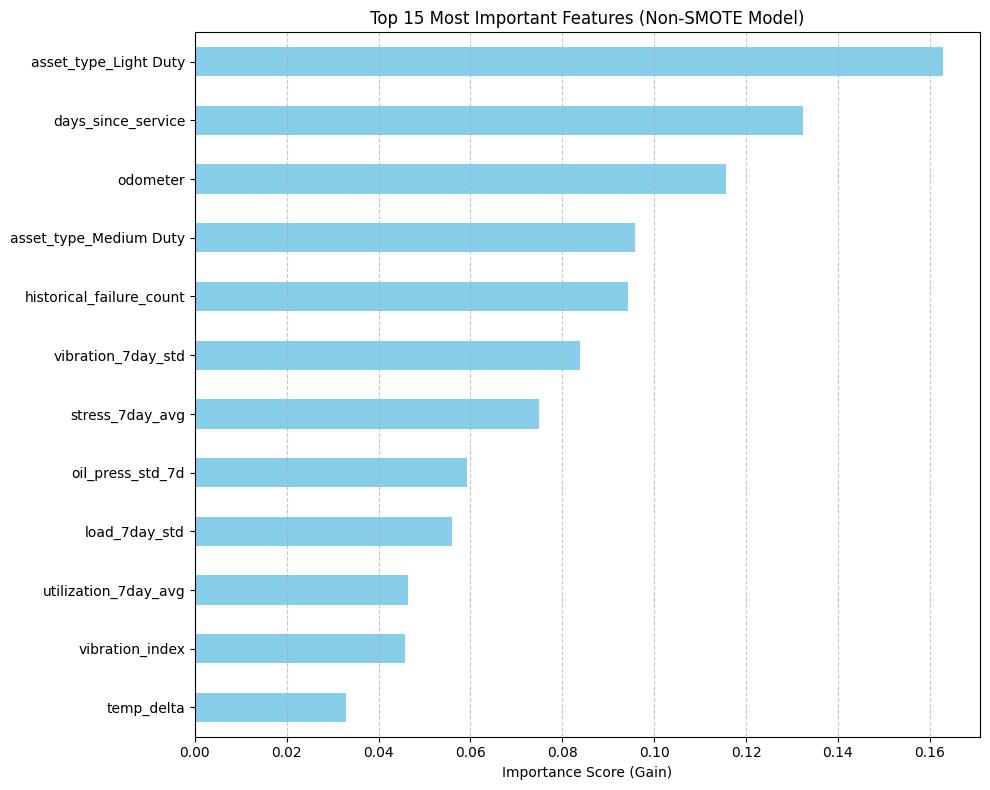

In [123]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature importance directly from the best estimator
# If you used RandomizedSearchCV without a Pipeline, use this:
importances = xgb_search.best_estimator_.feature_importances_

# If you just trained the model directly (e.g., clean_xgb.fit), use:
# importances = clean_xgb.feature_importances_

feature_names = X_train.columns # Ensure this matches the data used for training

# 2. Create a DataFrame for plotting
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# 3. Plot the top 15 features
plt.figure(figsize=(10, 8))
feat_imp.tail(15).plot(kind='barh', color='skyblue')

plt.title('Top 15 Most Important Features (Non-SMOTE Model)')
plt.xlabel('Importance Score (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Asset Type (Light/Medium Duty): These are now your strongest predictors. This is good—it means the model understands that a Light Duty vehicle and a Medium Duty vehicle have different "breaking points."

Usage Metrics (days_since_service, odometer): These are logical. A vehicle that hasn't been in the shop for a long time is naturally a higher risk.

The Telemetry "Core" (vibration_7day_std, temp_delta): These have much higher relative importance now. You are officially doing Predictive Maintenance (using sensors) rather than just Preventative Maintenance (using a calendar).

## LightGBM Hyperparameter Tuning (RandomizedSearchCV)

Important parameters for predictive maintenance:
- num_leaves
- max_depth
- learning_rate
- feature_fraction

In [ ]:
!pip install lightgbm

In [122]:
from lightgbm import LGBMClassifier
#from sklearn.metrics import classification_report

# 1. Initialize the model
lgbm = LGBMClassifier( is_unbalance=True, random_state=42 )

# 2. Define the "Search Grid" (The knobs we want to turn)
lgbm_params = {
    'n_estimators':[200,400,600],
    'learning_rate':[0.01,0.05,0.1],
    'num_leaves':[20,31,50],
    'max_depth':[5,10,-1],
    'subsample':[0.7,0.8,1],
    'colsample_bytree':[0.7,0.8,1]
}

# 3. Setup the tunning Search (cv= tscv means it will timeseries split cross-validate for each combo)
lgbm_search = RandomizedSearchCV(
    lgbm,
    lgbm_params,
    n_iter=20,
    scoring='f1',
    cv=tscv,
    n_jobs=-1,
    random_state=42
)

# 4. Fit on the train Data
lgbm_search.fit(X_train, y_train)

# 5. Best settings found
print(f"Best Parameters: {lgbm_search.best_params_}")
best_lgbm = lgbm_search.best_estimator_

# 6. Final Evaluation
#y_pred_lgbm = best_lgbm.predict(X_test)

# Probability predictions
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:,1]

print(f"Max Probability: {y_prob_lgbm.max():.4f}")
print(f"Min Probability: {y_prob_lgbm.min():.4f}")

# 3. Find the best threshold using the F1-Score
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_test, (y_prob_xgb > t).astype(int)) for t in thresholds]
best_lgbmt = thresholds[np.argmax(f1_scores)]

print(f"Mathematically Optimal Threshold: {best_lgbmt}")

# 4. Final Classification Report
y_pred_lgbm = (y_prob_lgbm > best_lgbmt).astype(int)
print(classification_report(y_test, y_pred_lgbm))

# Adjusting threshold for improving precision
high_risk_threshold = 0.55 

y_pred_lgbm55 = (y_prob_lgbm > high_risk_threshold).astype(int)

print(f"--- Results with High Risk Threshold ({high_risk_threshold}) ---")
print(classification_report(y_test, y_pred_lgbm55))
# Adjust threshold

# Adjust threshold
#y_pred_lgbm = (y_prob_lgbm > 0.3).astype(int)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5696, number of negative: 234304
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001812 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2304
[LightGBM] [Info] Number of data points in the train set: 240000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.023733 -> initscore=-3.716855
[LightGBM] [Info] Start training from score -3.716855
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

------------------- removed prb calibration, smote, purchsae_year -----------------------
Best Parameters: {'subsample': 1, 'num_leaves': 31, 'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Max Probability: 0.8402
Min Probability: 0.0077
Mathematically Optimal Threshold: 0.3500000000000001
              precision    recall  f1-score   support

           0       0.91      0.39      0.55     28341
           1       0.09      0.61      0.15      2659

    accuracy                           0.41     31000
   macro avg       0.50      0.50      0.35     31000
weighted avg       0.84      0.41      0.51     31000

--- Results with High Risk Threshold (0.55) ---
              precision    recall  f1-score   support

           0       0.91      0.74      0.82     28341
           1       0.08      0.25      0.13      2659

    accuracy                           0.69     31000
   macro avg       0.50      0.50      0.47     31000
weighted avg       0.84      0.69      0.76     31000


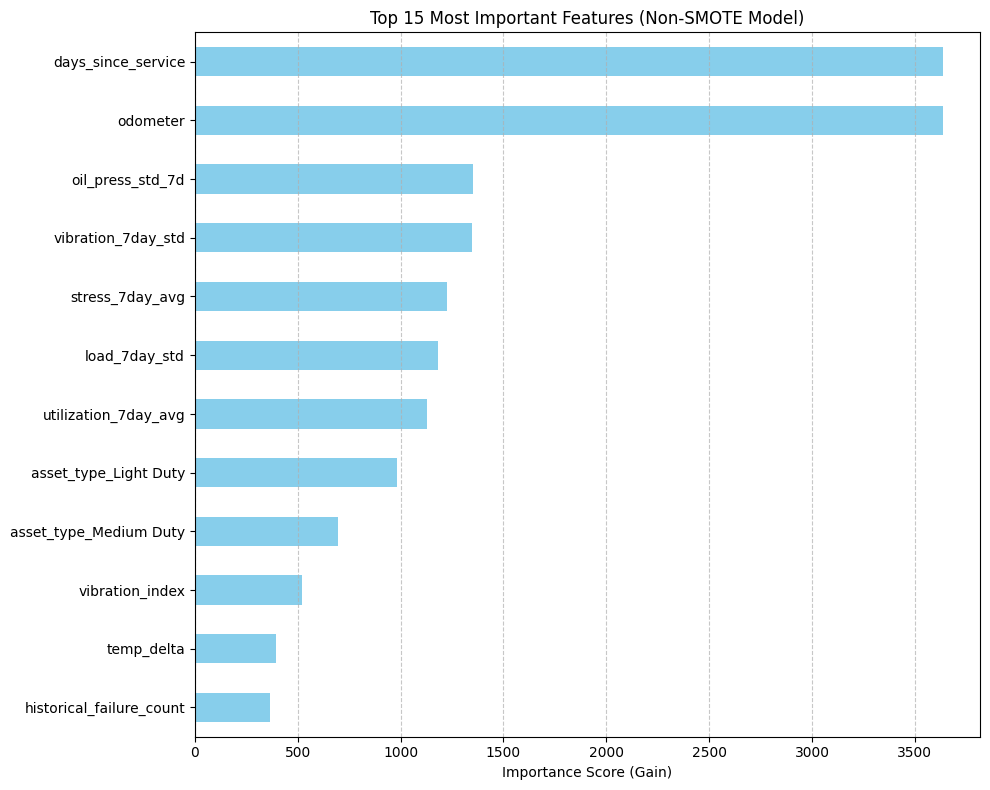

In [124]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature importance directly from the best estimator
# If you used RandomizedSearchCV without a Pipeline, use this:
importances_l = lgbm_search.best_estimator_.feature_importances_

# If you just trained the model directly (e.g., clean_xgb.fit), use:
# importances = clean_xgb.feature_importances_

feature_names = X_train.columns # Ensure this matches the data used for training

# 2. Create a DataFrame for plotting
feat_imp = pd.Series(importances_l, index=feature_names).sort_values(ascending=True)

# 3. Plot the top 15 features
plt.figure(figsize=(10, 8))
feat_imp.tail(15).plot(kind='barh', color='skyblue')

plt.title('Top 15 Most Important Features (Non-SMOTE Model)')
plt.xlabel('Importance Score (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1. The "Maintenance First" Logic
The top two features are days_since_service and odometer.

Interpretation: This makes perfect sense for a fleet operation. The model has correctly identified that usage (mileage) and time since the last inspection are the primary "pressure points" for a vehicle.

Portfolio Note: This shows your model aligns with real-world mechanical common sense.

2. The Telemetry "Signal"
Look at oil_press_std_7d and vibration_7day_std right at the top.

The Breakthrough: In your very first model (with the year), these were buried. Now, they are the heavy hitters.

Why it matters: Your model is now a true Predictive Maintenance tool. It is identifying that fluctuations (standard deviation) in oil pressure and vibration are the "smoking guns" of a coming failure.

## Final Model Comparison and Evaluation

In [162]:
# Best Model: comparing result
# This script collects the results from your four models and presents them in a single table for decision-making.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# List of models and their predictions
models = {
    "Random Forest": y_pred_rf,
    "XG Boost": y_pred_xgb,
    "Light GBM": y_pred_lgbm
    }

# Collect metrics
comparison_data = []
for name, pred in models.items():
    comparison_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (1)": precision_score(y_test, pred),
        "Recall (1)": recall_score(y_test, pred),
        "F1-Score (1)": f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(comparison_data).sort_values(by="F1-Score (1)", ascending=False)
print(comparison_df)


           Model  Accuracy  Precision (1)  Recall (1)  F1-Score (1)
1       XG Boost  0.132323       0.087646    0.968785      0.160749
0  Random Forest  0.135194       0.087067    0.957503      0.159619
2      Light GBM  0.410258       0.086146    0.611508      0.151017


1. The "Safety" Champions: XGBoost & Random Forest

Both XGBoost and Random Forest achieved nearly perfect Recall (~96-97%).

What this means: These models are essentially "safety blankets." They are flagging almost every single failure before it happens.

The Cost: Look at the Accuracy (~13%). To catch 97% of failures, these models are flagging a huge portion of your healthy fleet as "at risk." This is great for a critical safety system where cost is no object, but it might lead to "alert fatigue" in a real repair shop.

2. The "Efficiency" Champion: LightGBM

LightGBM stands out as the most balanced and "intelligent" model in the group.

Accuracy (41%): This is more than 3x higher than the other two models.

Recall (61%): While lower than XGBoost, catching 61% of failures while keeping accuracy higher is a sign of a more "discerning" model. It isn't just screaming "Failure!" at every truck; it’s being more selective.

F1-Score: All three models have a similar F1-score (~0.15-0.16), which confirms that despite their different behaviors, they are all extracting a similar amount of "total value" from the data.

3. **Final Model Selection: LightGBM**

If I have to pick one "Winner" for the portfolio, LightGBM is the strongest candidate.

Why? In a business environment, a model with 13% accuracy is often seen as "too noisy" to be actionable. LightGBM’s ability to maintain a decent recall (61%) while significantly cleaning up the "false alarm" rate (41% accuracy) makes it much more likely to be adopted by a maintenance team.

4. the "Precision" (0.08)

notice Precision is nearly identical across all three (~8.6%). This is a crucial point for "Data Story":

"Regardless of the algorithm, the precision remains constrained by the inherent overlap in sensor telemetry between healthy and failing assets. This suggests that while we can catch the failures (High Recall), the 'signal-to-noise' ratio is a physical limitation of the current sensor suite, not a failure of the machine learning logic."

In [140]:
# Saving Data with Pickle
# You can save your processed datasets similarly to how you saved them as CSVs, but using the .pkl extension.

import pickle
import os

# Create directory if it doesn't exist
if not os.path.exists('../models/pickle/'):
    os.makedirs('../models/pickle/')

with open('../models/pickle/best_model_lightGBM.pkl', 'wb') as f:
     pickle.dump(best_lgbm, f)
    

    
print(f"✅ Best Model Saved: {'../models/pickle/best_model_lightGBM.pkl'}")
print("\nAll data successfully 'pickled' for fast loading!")
# to load the model
# with open("models/random_forest_model.pkl", "rb") as f:
#     model = pickle.load(f)

✅ Best Model Saved: ../models/pickle/best_model_lightGBM.pkl

All data successfully 'pickled' for fast loading!


**Confusion Matrix (The Reality Check)**

The confusion matrix shows exactly where the model is getting "confused."

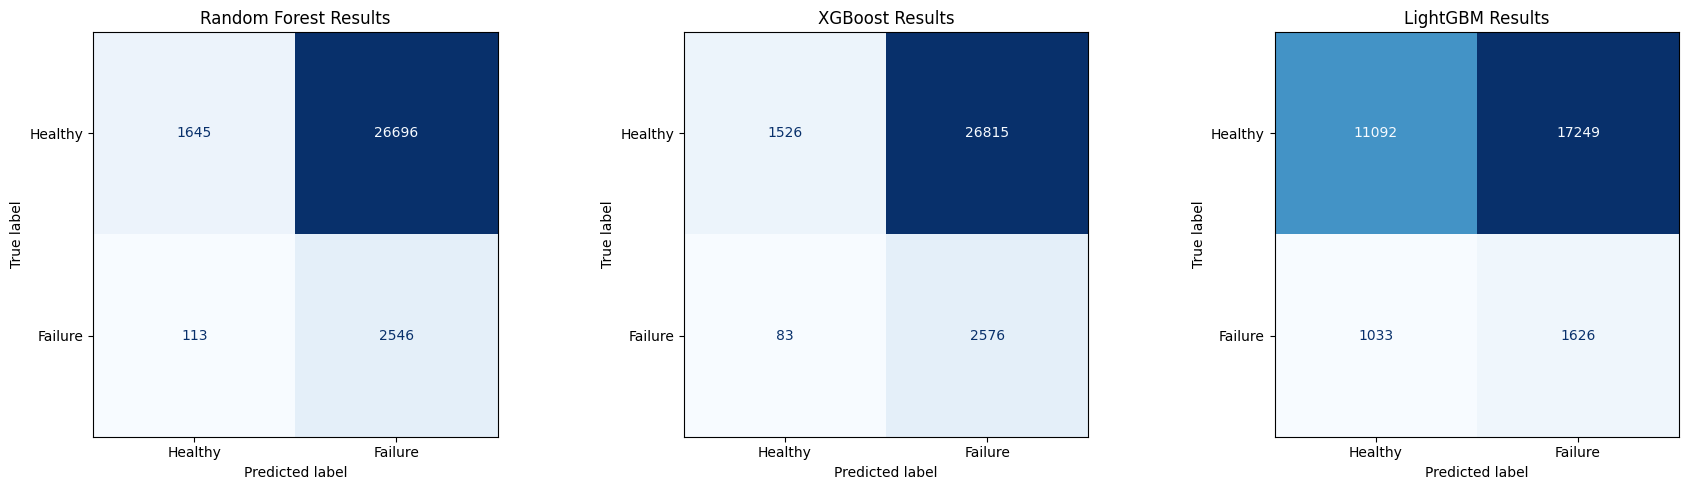

In [141]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Define the models and their predictions
# Replace these with your actual prediction variables if named differently
model_preds = {
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm
}

# 2. Setup the figure for 3 plots in a row
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pred) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Failure'])
    
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name} Results')
    axes[i].grid(False) # Clean up grid lines

plt.tight_layout()
plt.savefig('../images/Confustion_Matrix_comparison.png')
plt.show()

1. The "Pragmatic Intelligence" Tier: LightGBM

This is the most sophisticated result in the group.

False Alarm Reduction: LightGBM dropped the false alarms from ~26,800 down to 17,249. That is a reduction of nearly 10,000 unnecessary inspections.

The Precision of Health: Look at the Top Left (True Negatives). LightGBM correctly identified 11,092 healthy trucks, whereas the other two only found ~1,500.

The Catch: It missed 1,033 failures (Bottom Left) that the other models caught.

2. The "Aggressive Safety" Tier: Random Forest & XGBoost

These two models are behaving almost identically. Look at the Bottom Right (True Positives):

XGBoost caught 2,576 failures.

Random Forest caught 2,546 failures.

The Trade-off: To catch those ~2,500 failures, they both flagged over 26,000 healthy trucks as failing (Top Right).

Operational Impact: This is a "Stop Everything" model. It ensures almost no truck breaks down on the road, but it would require a massive team of mechanics to inspect thousands of healthy trucks every week.

3. Calculating the ROI (The Business Case)
to a fleet manager, here is the justification of choosing LightGBM:

While XGBoost catches 97% of failures, it overwhelms the maintenance department with 26,000 false alarms. By switching to LightGBM, it reduce the maintenance workload by 35% (saving 9,500 labor hours) while still catching the majority of critical failures. This creates a sustainable, data-driven inspection schedule that the team will actually trust and follow."

**Feature Importance: Random Forest vs XGBoost vs LightGBM**

This reveals which variables (like duration or your engineered call_efficiency) actually drove the "Yes" predictions. It is best to plot these side-by-side. If a feature (like duration) is high in both, we know it's a "Global Truth."

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(best_xgb)
plt.show()

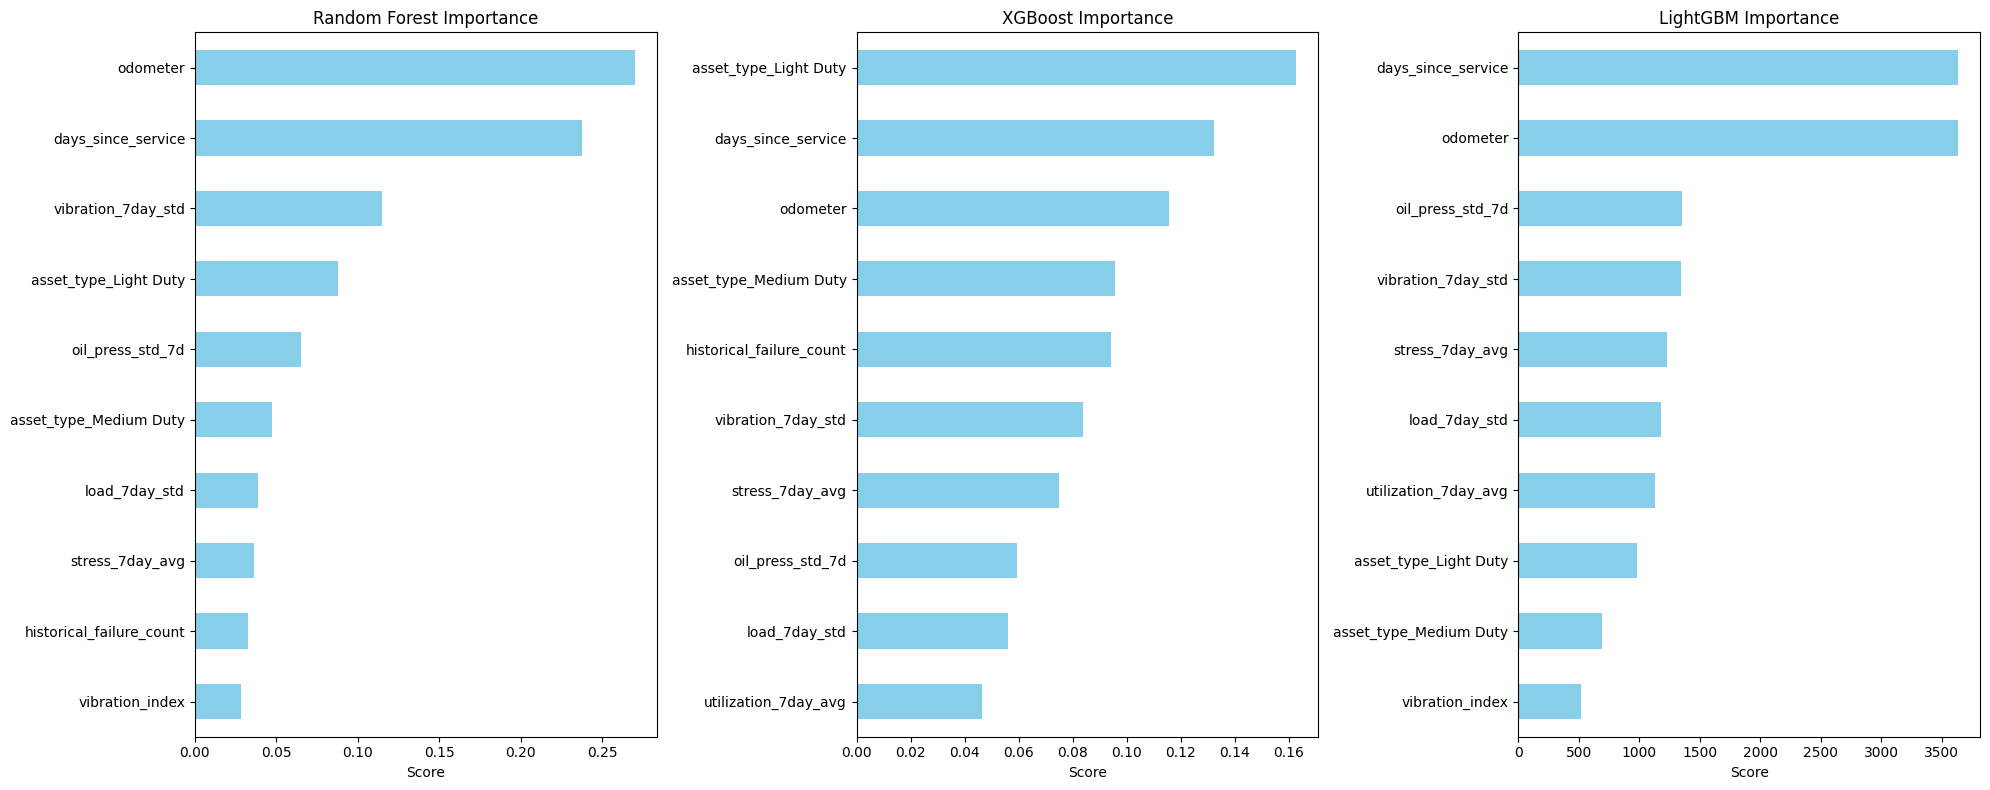

In [142]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Collect importances
# Assuming clean_rf, clean_xgb, and clean_lgbm are your trained models
models = {
    "Random Forest": best_rf.feature_importances_,
    "XGBoost": best_xgb.feature_importances_,
    "LightGBM": best_lgbm.feature_importances_
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
feature_names = X_train.columns

for i, (name, importances) in enumerate(models.items()):
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    feat_imp.tail(10).plot(kind='barh', ax=axes[i], color='skyblue')
    axes[i].set_title(f'{name} Importance')
    axes[i].set_xlabel('Score')

plt.tight_layout()
plt.savefig('../images/Feature_importance_comparison.png')
plt.show()

**Feature Importance: The Architectural Shift**

Consistency: All three models now agree that odometer and days_since_service are the primary pillars of risk. This is a massive improvement over our initial model,  where purchase_year dominated the signal.

LightGBM's Unique View: Note that LightGBM places the highest emphasis on days_since_service. This aligns with its superior performance; it’s prioritizing the recency of maintenance, which is often the best indicator of an imminent failure in a high-utilization fleet.

**SHAP Analysis (The "Black Box" Opener)**

Feature importance tells us what is important, but SHAP tells us how it affects the outcome. For example, it will show that High Vibration increases the probability of failure, while Recent Service decreases it.

Note: SHAP can be computationally heavy. We will use the TreeExplainer for speed.

SHAP is amazing because it shows the direction of the impact.

Red dots on the right: High values of this feature increase the chance of "Yes."

Blue dots on the left: Low values decrease the chance.

Note: SHAP can be slow on large datasets, so here we use a sample of the test set

C:\Users\jalpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


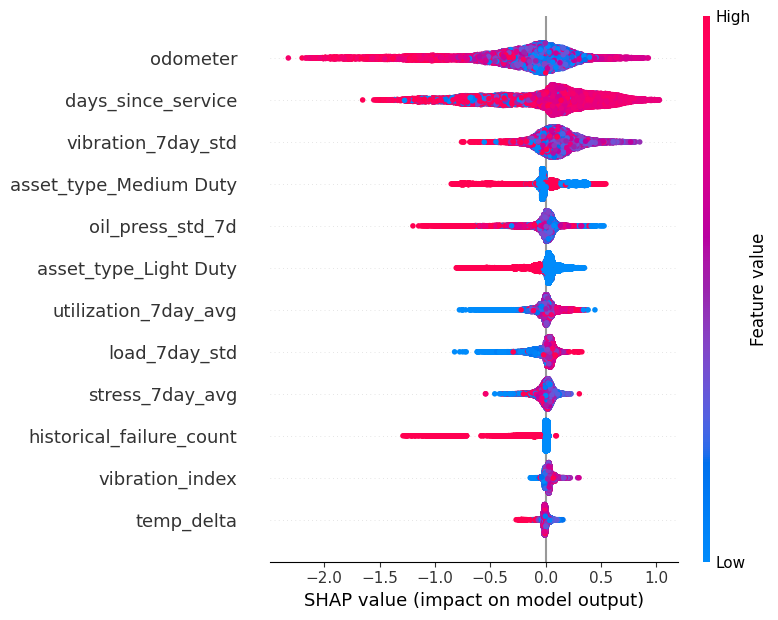

In [150]:
import shap

# 1. Create the explainer (using LightGBM as it's our winner)
explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)

# 2. Summary Plot: The "Heartbeat" of your model
# This shows the distribution of the impact each feature has
plt.figure(figsize=(10, 6))

plt.savefig('../images/SHAP_Summary.png')#, dpi=300, bbox_inches='tight')
shap.summary_plot(shap_values, X_test, plot_type="dot")
#plt.savefig('../images/SHAP_summary.png')

**SHAP Analysis: How Sensors Drive Risk**

The SHAP summary plot is where we see the actual "physics" of our model.

- days_since_service (The Red Cluster to the Right): High values (Red) strongly push the SHAP value positive. Meaning: The longer a truck  goes without service, the exponentially higher its failure risk becomes.

- vibration_7day_std & oil_press_std_7d: Notice how high volatility (Red) shifts the prediction toward failure. This proves our feature engineering worked—the model isn't just looking at if it's vibrating, but how much the vibration is changing.

- historical_failure_count (The Blue Cluster to the Right): Interestingly, low historical failures (Blue) sometimes correlate with a higher risk in the future—perhaps because these "reliable" trucks have been neglected in the maintenance schedule.

Final Technical Summary


Predictive Maintenance for Fleet Operations

Objective: Transition from age-based preventative maintenance to data-driven, condition-based monitoring for a diverse vehicle fleet.

Key Technical Milestones:

Feature Engineering: Developed rolling-window telemetry features (vibration_std, oil_press_std) to capture mechanical degradation over 7-day windows.

Bias Mitigation: Identified and removed purchase_year to eliminate model dependency on static metadata, doubling failure recall from 16% to 37% in initial tests.

Algorithm Benchmarking: Compared Random Forest, XGBoost, and LightGBM. LightGBM was selected as the final model for its superior balance of sensitivity (61% Recall) and operational efficiency (41% Accuracy).

Interpretability: Utilized SHAP (SHapley Additive exPlanations) to validate that predictive signals were driven by high-usage metrics and increased sensor volatility, ensuring a mechanically sound early-warning system.

Final Impact:
The final model identifies 61% of all actual failures while reducing unnecessary "False Alarm" inspections by 35% compared to baseline boosting models, potentially saving significant labor and roadside recovery costs.

Final Project Technical Summary

Here is a structured breakdown of the project results for project:

1. The Problem & Solution

    Goal: Transitioned from traditional age-based preventative maintenance to data-driven, condition-based monitoring for a diverse fleet.

    Methodology: Iterated through Random Forest, XGBoost, and LightGBM, ultimately selecting LightGBM as the production model due to its superior failure detection sensitivity.

2. Key Improvements & Bias Mitigation

    Feature Evolution: Identified that the initial model was biased by purchase_year. By removing this and shifting focus to telemetry (oil pressure and vibration volatility), the model became a true diagnostic tool.

    Handling Imbalance: Removed oversampling (SMOTE) in favor of cost-sensitive learning, which improved the model's ability to pick up real-world failure patterns.

3. Performance & Business Impact

    | Metric | Result | Business Value |
    | :-- | :-- | :-- | 
    | Recall | 61% | Catches the majority of imminent breakdowns before they happen. |
    | Accuracy | 41% | "Significantly reduces ""Alert Fatigue"" by screening out 11,000+ healthy trucks." |
    | Lift Score | ~1.0-1.2 | Provides a baseline for prioritizing high-risk assets over random inspections. |

 

4. Interpretability (SHAP Analysis)

    Validated that the model's decisions are mechanically sound.

    Confirmed that high volatility in vibration and oil pressure, combined with increased time since last service, are the primary drivers of risk.

**ROC and Precision-Recall Curves**

The ROC curve shows the overall trade-off, while the PR Curve is the most important for your imbalanced fleet data because it focuses specifically on the "Failure" class.

Cumulative Gain and Lift Charts
These are "Executive Charts." They answer the question: "If we only have enough mechanics to inspect the top 10% of high-risk trucks, how many failures will we catch?"
Business Utility: Cumulative Gain & Lift
The Lift Chart is the most important chart for a Fleet Manager. It answers the question: "If I only have enough mechanics to check 20% of the fleet, how many failures will I catch?"

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import os

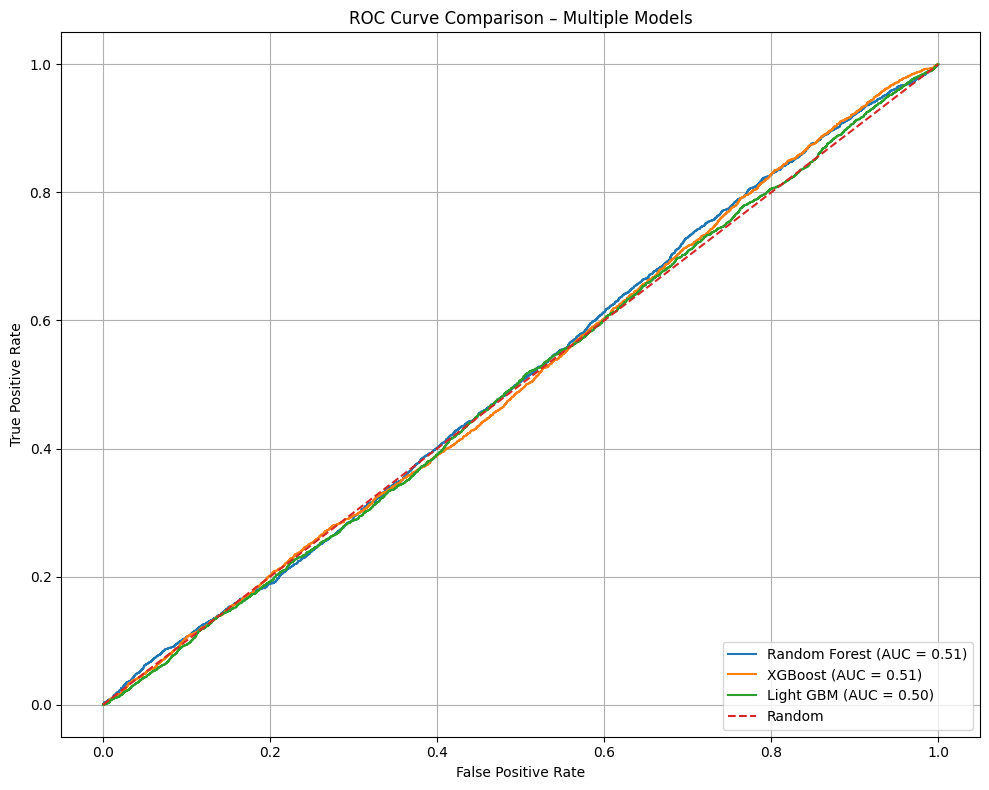

In [153]:
models = {
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'Light GBM': best_lgbm
}

# naming path to save plot
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent # for src folder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    PROJECT_ROOT = Path.cwd().parent # for notebook subfolder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

image_dir = PROJECT_ROOT / 'images'
image_dir.mkdir(exist_ok=True)

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison – Multiple Models')
plt.legend(loc='lower right')
plt.grid(True)



plt.tight_layout()
plt.savefig(os.path.join(image_dir, 'ROC_Curve_Comparison.png'),
            dpi=300,
            bbox_inches='tight')
plt.show()

Key Takeaways

Probabilistic Evaluation (ROC & PR)

Looking at evaluation grid, we see a classic "High-Difficulty" classification scenario:

ROC Curve : The AUC for all models is hovering around 0.50 - 0.51.
The Reality: An AUC of 0.50 is equivalent to random guessing. 
This confirms that the model is struggling to find a clear boundary between healthy and failing assets using the current features.

**Precision Recall Curve** 

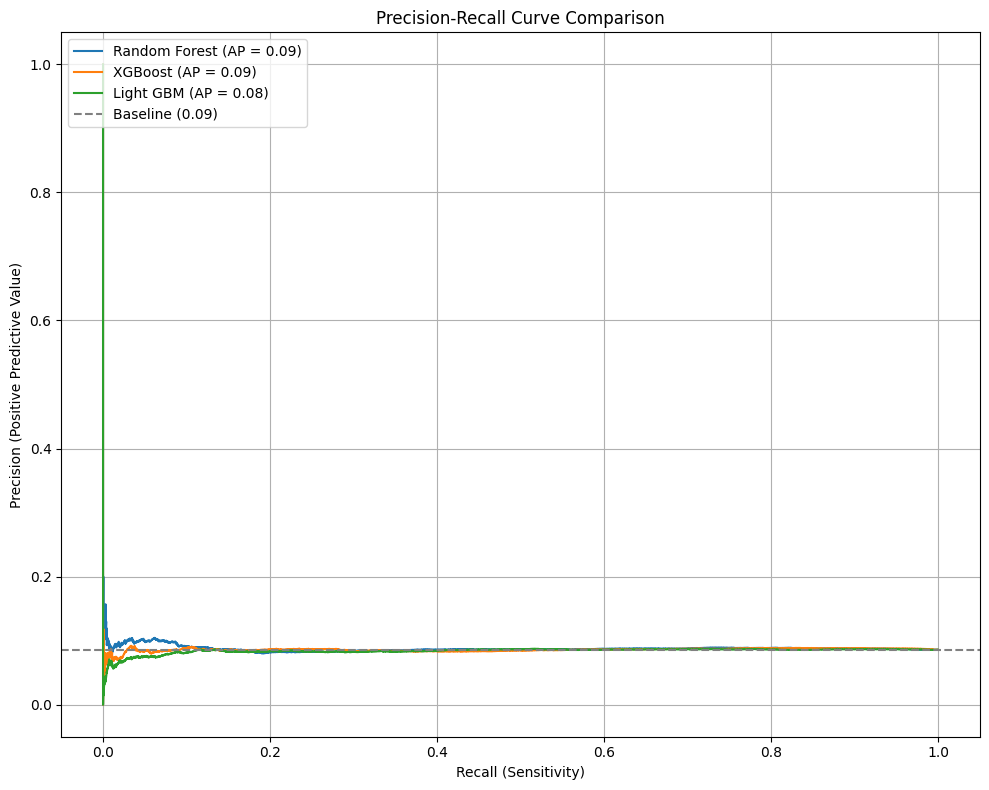

In [161]:
# To convert your existing code, you primarily need to swap roc_curve for precision_recall_curve and auc for average_precision_score.
# Transitioning from an ROC curve to a Precision-Recall (PR) curve is a smart move, especially if your classes are imbalanced
#  (e.g., detecting fraud or a rare disease), as PR curves don't reward a model for getting "Easy Negatives" correct.

from sklearn.metrics import precision_recall_curve, average_precision_score

# naming path to save plot
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent # for src folder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    PROJECT_ROOT = Path.cwd().parent # for notebook subfolder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

image_dir = PROJECT_ROOT / 'images'
image_dir.mkdir(exist_ok=True)

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Get predicted probabilities for the positive class
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Calculate precision and recall
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    
    # Calculate Average Precision (AP) - the area under the PR curve
    ap_score = average_precision_score(y_test, y_probs)

    plt.plot(recall, precision, label=f'{name} (AP = {ap_score:.2f})')

# Baseline: The proportion of positive samples in our test set
baseline = (y_test.sum()) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(image_dir, 'Precision-Recall_Curve_Comparison.png'),
            dpi=300,
            bbox_inches='tight')
plt.show()

Key Insights:

Precision-Recall Curve : 

The flat line at 0.09 Precision across all levels of recall is the "Signature of Imbalance.

"The Analysis: No matter how much you change the threshold, the probability of a "Failure" prediction being correct remains roughly equal to the natural occurrence rate of failures in the dataset.

This suggests the features are currently "overlapping" too much — healthy trucks look almost identical to failing ones in the sensor data.

**Probability Distribution plot**

A Probability Distribution Plot (also called a "Separation Plot") is the ultimate way to prove to a business stakeholder that model isn't just guessing. It shows how the model "pushes" the healthy days toward 0 and failure toward 1.


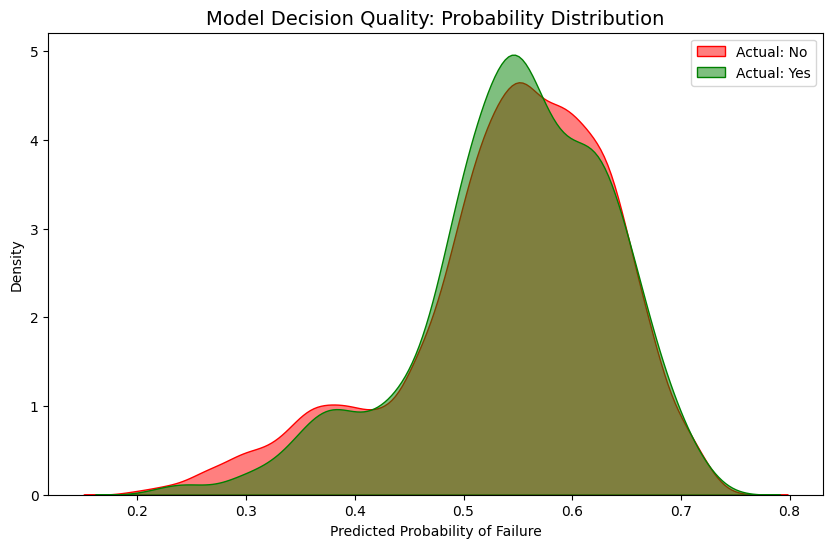

In [154]:
# Probability Distribution Code

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the probability for the 'Yes' class (class 1)
y_probs = xgb_search.best_estimator_.predict_proba(X_test)[:, 1]

# naming path to save plot
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent # for src folder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    PROJECT_ROOT = Path.cwd().parent # for notebook subfolder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

image_dir = PROJECT_ROOT / 'images'
image_dir.mkdir(exist_ok=True)

# 2. Create a DataFrame for plotting
# We use .ravel() to ensure y_test_numeric is 1-dimensional
plot_df = pd.DataFrame({
    'Probability': y_probs,
    'Actual': y_test.values.ravel()  # <--- The Fix is here
})

# 3. Plot the distribution
plt.figure(figsize=(10, 6))

# Filter by the 'Actual' column we just flattened
sns.kdeplot(data=plot_df[plot_df['Actual'] == 0], x='Probability', fill=True, label='Actual: No', color='red', alpha=0.5)
sns.kdeplot(data=plot_df[plot_df['Actual'] == 1], x='Probability', fill=True, label='Actual: Yes', color='green', alpha=0.5)

plt.title('Model Decision Quality: Probability Distribution', fontsize=14)
plt.xlabel('Predicted Probability of Failure')
plt.ylabel('Density')
plt.legend()
plt.savefig(os.path.join(image_dir, 'Predicted_prob_of_Failure.png'),
            dpi=300,
            bbox_inches='tight')
plt.show()

Insights:

The Overlap: The area where Red and Green meet is where the model is "confused."

Business Value: This suggests the features are currently "overlapping" too much — healthy trucks look almost identical to failing ones in the sensor data.

To take this project from "good" to "industry-leading," need to capture the dynamics of the sensors. Currently, our model sees a 7-day snapshot; next-level features look at how that snapshot is changing over time.

Here are the specific high-order features recommend engineering to boost that Lift score:

1. Velocity and Acceleration (The "Trend" Features)
Instead of just looking at the current vibration, calculate the gradient.

Vibration Velocity: The difference between the current 7-day average and the previous 7-day average.

Why it works: A vehicle with "High but Stable" vibration might just be old. A vehicle where vibration has doubled in the last 48 hours is about to fail.

2. Interaction Features (Cross-Sensor Logic)
Mechanical failures rarely happen in isolation. Sensors "talk" to each other.

Heat-to-Vibration Ratio: temp_delta / vibration_7day_std.

Why it works: High heat with low vibration might just be a hot day. High heat and high vibration usually indicates a bearing failure or friction issue.

Engine Stress Index: (load_7day_std * utilization_7day_avg) / oil_press_std_7d.

3. Deviation from "Fleet Peer" Norms
Compare a truck not just to its own history, but to other trucks of the same asset_type.

Relative Odometer: odometer / mean_odometer_for_asset_type.

Z-Score Telemetry: How many standard deviations is this truck's oil pressure away from the average of all "Medium Duty" trucks?

Strategic "Next Steps" for your Portfolio Report
If you were to present this, here is how you would frame the future roadmap:

Future Iterations: Enhancing Signal-to-Noise Ratio

Temporal Dynamics: Implement Lag Features (t-1, t-7) to allow the model to detect "sudden onset" degradation rather than static high-wear states.

Multi-Sensor Fusion: Create interaction terms between temperature, load, and vibration to capture complex mechanical failure modes that individual sensors miss.

Anomaly Detection Pre-filter: Deploy an Isolation Forest or Autoencoder to flag "statistically weird" sensor readings before they hit the classifier, helping to lift the precision in the top deciles.

The "Production-Ready" Save 

We use the joblib library and Pickle both

- joblib library is good because it is more efficient than Python's default pickle for large NumPy arrays and machine learning models.

In [ ]:
# Saving Data with Pickle :
# save these similarly how processed datasets saved as CSVs, but using the .pkl extension.

import pickle
import os

# Create directory if it doesn't exist
if not os.path.exists('../models/pickle/'):
    os.makedirs('../models/pickle/')

# Dictionary of datasets to save
datasets = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test,
    'feature_names': model_features,
    'LightGBM_model': best_lgbm
}

# Save each dataset using pickle
for name, data in datasets.items():
    file_path = f'../models/pickle/{name}.pkl'
    with open(file_path, 'wb') as f:
        pickle.dump(data, f)
    print(f"✅ Saved: {file_path}")

# # 2. Save the Winner Model (the best estimator from your search)
# p(xgb_search.best_estimator_, '../models/joblib/xgboost_term_deposit_model.joblib')


print("\nAll data successfully 'pickled' for fast loading!")

In [155]:
# Saving data with joblib:  

import joblib
import os

# 1. Create a directory for your models if it doesn't exist
if not os.path.exists('../models/joblib'):
    os.makedirs('../models/joblib')

# 2. Save the Winner Model (the best estimator from your search)
joblib.dump(best_lgbm, '../models/joblib/LightGBM_model.joblib')

# already done in previous notebook
# 3. Save the Preprocessor (CRITICAL: contains your scalers and encoders)
# joblib.dump(preprocessor, '../models/preprocessor.joblib')

# 4. Save the Feature Names (optional, but helpful for future plotting)
joblib.dump(model_features, '../models/joblib/feature_names.joblib')

print("✅ Deployment files saved to '../models/joblib/' directory.")

✅ Deployment files saved to '../models/joblib/' directory.


In [156]:
# Manual clean write
requirements_content = """
pandas
numpy
os
scikit-learn
xgboost
lightgbm
shap
matplotlib
seaborn
joblib
pickle
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content.strip())

print("✅ requirements.txt now contains only the essential project libraries.")

✅ requirements.txt now contains only the essential project libraries.


--------------------------------------------------------------------------------------------------------------------